# 7주차

## 데이터 시각화

matplotlib 라이브러리 사용

> > matpolitlib란? Python에서 그래프, 차트 등을 그리는데 사용하는 라이브러리



In [1]:
%pip install matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------------------------- -------- 6.6/8.3 MB 32.4 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 34.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 45.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 43.9 MB/s  0:00:00

   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- -------

In [2]:
import matplotlib.pyplot as plt
import matplotlib
import platform

# 한글이 깨지는 경우, 운영체제에 맞게 한글 폰트 지정
if platform.system() == "Windows":
    #윈도우: 폰트 '맑은 고딕' 사용
    matplotlib.rc("font", family = "Malgun Gothic")
elif platform.system() == "Darwin":
    #맥: 폰트 '애플 고딕' 사용
    matplotlib.rc("font", family = "AppleGothic")
else:
    #리눅스: 폰트 '나눔 고딕' 사용
    matplotlib.rc("font", family = "NanumGothic")

#마이너스 기호 깨짐 방지
matplotlib.rc("axes", unicode_minus=False)

#위에서 pip install한 후 커널 리스타트를 눌러줬으면 코드 왼쪽에 실행 버튼을 꼭 눌러서 재시작해주기.

## Line Chart (꺾은선 그래프)

- 시간에 따른 변화를 보여줄 때, 가장 많이 사용함  
- 예: 날씨 - 월 별로 변화하는 기온  
- 아래에 코드로 생성

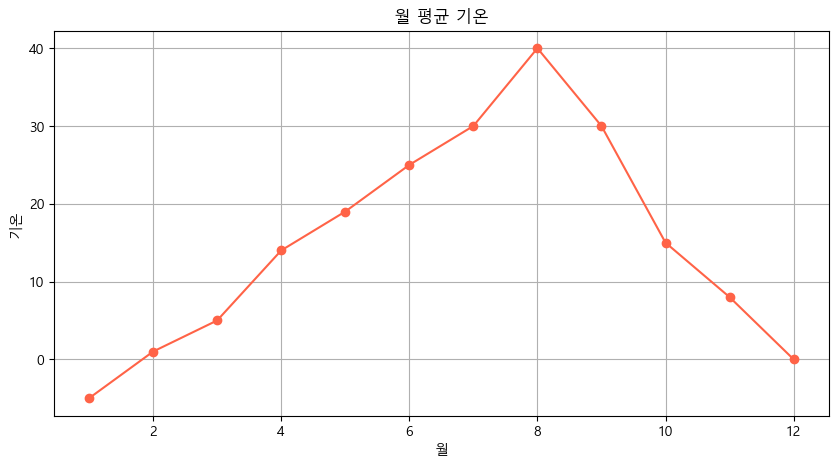

In [3]:
# 월 평균
months = [1 ,2 ,3 ,4 ,5 ,6 ,7 ,8 ,9 ,10,11,12]
temps =  [-5,1 ,5 ,14,19,25,30,40,30,15,8 ,0 ]

#그래프 그리는 순서:
# 1. plt.figure(도화지) - figsize는 크기(가로, 세로)를 의미
plt.figure(figsize=(10, 5))
# 2. 꺾은선 그래프 그리기 - marker는 데이터 위치에 표시되는 점, color는 테마
plt.plot(months, temps, marker="o", color="tomato")
# 3. 제목과 축 라벨 설정
plt.title("월 평균 기온")
plt.xlabel("월")
plt.ylabel("기온")
# 4. 보조선(Grid) 추가
plt.grid(True)
plt.show()

# 막대 그래프

> 항목별 값을 비교할 때 사용

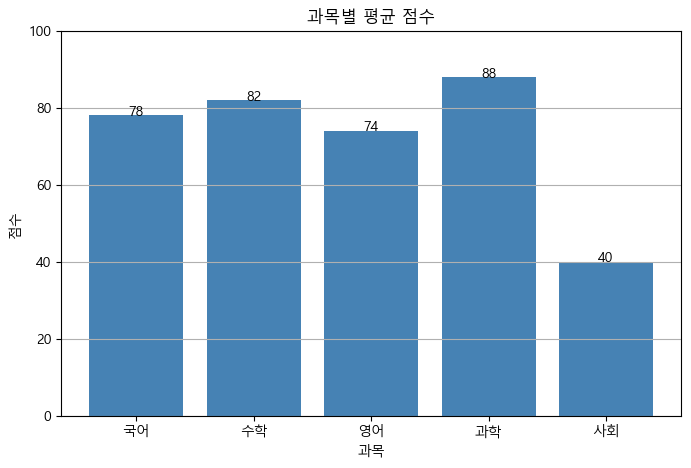

In [4]:
# 과목별 평균 점수 데이터
subjects   = ["국어", "수학", "영어", "과학", "사회"]
avg_scores = [78    , 82    , 74    , 88    , 40  ]

plt.figure(figsize=(8,5))
plt.bar(subjects, avg_scores, color="steelblue")
plt.title("과목별 평균 점수")
plt.xlabel("과목")
plt.ylabel("점수")
plt.ylim(0, 100) #y축의 범위 지정: lim = limit / 0부터 100점까지
plt.grid(axis="y") #y축에 대해서 그래프 내부에 보조선 지정
#테스트를 추가하는건데 ha="center"가 없으면 오른쪽 정렬 / 위치 수식을 붙이면 가운데정렬 / x축은 위치, y축이 점수인점 참고 
for i, score in enumerate(avg_scores):
    plt.text(i, score, str(score), ha="center")

plt.show()

## 문제:

##### 응용
과목별 평균점수를 막대 그래프 상단에 표시하기

>위에 막대그래프에 추가로 코딩 후 주석처리로 구분
>수업 시간에 영어에 대해서는 '테스트'로 표시를 했었기 때문에 영어부분에 테스트 글씨도 평균점수로 수정해서 처리하였습니다

# 산점도 (Scatter Plot)

두 수치 데이터 사이의 관계(상관관계)를 점으로 나타낸 그래프

>머신러닝에서 특성(feature)간의 관계를 시각적으로 파악할 때 사용

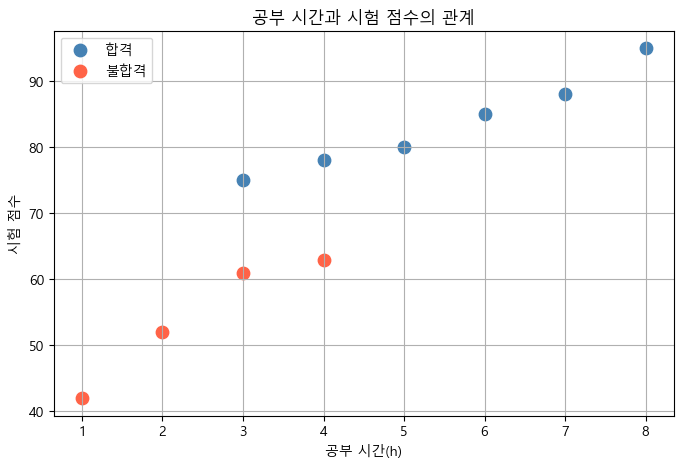

In [5]:
# 공부 시간과 점수의 관계
# 70점 이상은 합격
study     = [1 , 2 , 3 , 3 , 4 , 4 , 5 , 6 , 7 , 8 ]
score     = [42, 52, 61, 75, 63, 78, 80, 85, 88, 95]
pass_fail = [0 , 0 , 0 , 1 , 0 , 1 , 1 , 1 , 1 , 1 ]

# 합격/불합격 분리
pass_study = [study[i] for i in range(len(pass_fail)) if pass_fail[i] == 1]
pass_score = [score[i] for i in range(len(pass_fail)) if pass_fail[i] == 1]
fail_study = [study[i] for i in range(len(pass_fail)) if pass_fail[i] == 0]
fail_score = [score[i] for i in range(len(pass_fail)) if pass_fail[i] == 0]

plt.figure(figsize=(8,5))

plt.scatter(pass_study, pass_score, color="steelblue", s=80, label="합격") #scatter를 두번 썼다는 건 두번 그렸다를 의미
plt.scatter(fail_study, fail_score, color="tomato", s=80, label="불합격") # s 매개변수들은 점의 크기

plt.title("공부 시간과 시험 점수의 관계")
plt.xlabel("공부 시간(h)")
plt.ylabel("시험 점수")
plt.legend()
plt.grid(True)
plt.show()